<a href="https://colab.research.google.com/github/Anj-7171/Transformer-network-for-trajectory-forecasting/blob/main/Transformer_Trajectory_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/FGiuliari/Trajectory-Transformer.git

Cloning into 'Trajectory-Transformer'...
remote: Enumerating objects: 163, done.
remote: Total 163 (delta 0), reused 0 (delta 0), pack-reused 163 (from 1)
Receiving objects: 100% (163/163), 2.46 MiB | 5.81 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [2]:
%cd Trajectory-Transformer

/content/Trajectory-Transformer


In [3]:
!pip install torch torchvision
!pip install numpy scipy matplotlib
!pip install scikit-learn
!pip install tensorboard

In [4]:
!pip install kmeans-pytorch

In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
import os
print("Train:", os.listdir("datasets/eth/train"))
print("Val:", os.listdir("datasets/eth/val"))
print("Test:", os.listdir("datasets/eth/test"))

Train: ['crowds_zara01_train.txt', 'biwi_hotel_train.txt', 'students003_train.txt', 'crowds_zara03_train.txt', 'crowds_zara02_train.txt', 'uni_examples_train.txt', 'students001_train.txt']
Val: ['biwi_hotel_val.txt', 'crowds_zara03_val.txt', 'crowds_zara02_val.txt', 'crowds_zara01_val.txt', 'students003_val.txt', 'uni_examples_val.txt', 'students001_val.txt']
Test: ['biwi_eth.txt']


In [15]:
!python train_individualTF.py \
--dataset_folder datasets \
--dataset_name eth \
--obs 8 \
--preds 12 \
--emb_size 64 \
--heads 4 \
--layers 2 \
--dropout 0.1 \
--batch_size 64 \
--max_epoch 3 \
--validation_epoch_start 5 \
--name eth_transformer_colab

2026-03-04 16:54:11.462256: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772643251.483137    5863 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772643251.490110    5863 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772643251.507512    5863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772643251.507550    5863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772643251.507554    5863 computation_placer.cc:177] computation placer alr

In [16]:
!ls output/Individual/eth_transformer_colab

det_0.mat  det_1.mat  det_2.mat


In [17]:
!ls models/Individual/eth_transformer_colab

00000.pth  00001.pth  00002.pth  norm.mat


In [19]:
import scipy.io as sio
import numpy as np

data = sio.loadmat("output/Individual/eth_transformer_colab/det_2.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'input', 'gt', 'pr', 'peds', 'frames', 'dt', 'dt_names'])


In [20]:
gt = data['gt']      # ground truth future
pr = data['pr']      # predicted future

# displacement error per timestep
error = np.linalg.norm(gt - pr, axis=-1)

# MAD = mean over all timesteps & samples
MAD = error.mean()

# FAD = error at final timestep
FAD = error[:, -1].mean()

print("MAD:", MAD)
print("FAD:", FAD)

MAD: 1.0361447
FAD: 2.0218961


Model was underperforming. Trying to improve the performance of the model by training for more epochs

In [21]:
!python train_individualTF.py \
--dataset_folder datasets \
--dataset_name eth \
--obs 8 \
--preds 12 \
--emb_size 128 \
--heads 8 \
--layers 4 \
--dropout 0.1 \
--batch_size 64 \
--max_epoch 50 \
--validation_epoch_start 1 \
--name eth_transformer_strong

Streaming output truncated to the last 5000 lines.
train epoch 041/050  batch 0085 / 0474 loss:  0.1436
train epoch 041/050  batch 0086 / 0474 loss:  0.1534
train epoch 041/050  batch 0087 / 0474 loss:  0.1310
train epoch 041/050  batch 0088 / 0474 loss:  0.1261
train epoch 041/050  batch 0089 / 0474 loss:  0.1264
train epoch 041/050  batch 0090 / 0474 loss:  0.1463
train epoch 041/050  batch 0091 / 0474 loss:  0.1295
train epoch 041/050  batch 0092 / 0474 loss:  0.1364
train epoch 041/050  batch 0093 / 0474 loss:  0.1542
train epoch 041/050  batch 0094 / 0474 loss:  0.1024
train epoch 041/050  batch 0095 / 0474 loss:  0.1333
train epoch 041/050  batch 0096 / 0474 loss:  0.1401
train epoch 041/050  batch 0097 / 0474 loss:  0.1532
train epoch 041/050  batch 0098 / 0474 loss:  0.1485
train epoch 041/050  batch 0099 / 0474 loss:  0.1523
train epoch 041/050  batch 0100 / 0474 loss:  0.1392
train epoch 041/050  batch 0101 / 0474 loss:  0.1540
train epoch 041/050  batch 0102 / 0474 loss:  0.

In [22]:
!ls output/Individual/eth_transformer_strong

det_0.mat   det_18.mat	det_26.mat  det_34.mat	det_42.mat  det_5.mat
det_10.mat  det_19.mat	det_27.mat  det_35.mat	det_43.mat  det_6.mat
det_11.mat  det_1.mat	det_28.mat  det_36.mat	det_44.mat  det_7.mat
det_12.mat  det_20.mat	det_29.mat  det_37.mat	det_45.mat  det_8.mat
det_13.mat  det_21.mat	det_2.mat   det_38.mat	det_46.mat  det_9.mat
det_14.mat  det_22.mat	det_30.mat  det_39.mat	det_47.mat
det_15.mat  det_23.mat	det_31.mat  det_3.mat	det_48.mat
det_16.mat  det_24.mat	det_32.mat  det_40.mat	det_49.mat
det_17.mat  det_25.mat	det_33.mat  det_41.mat	det_4.mat


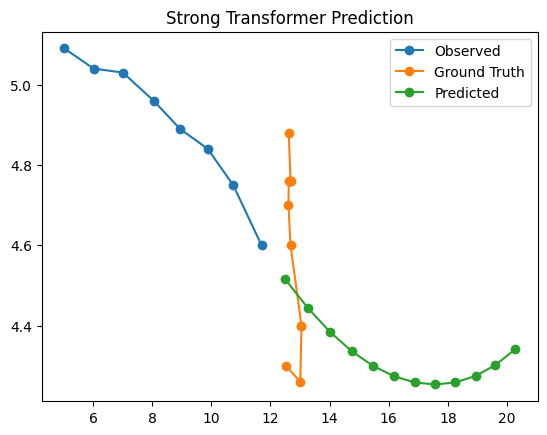

In [29]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, gt.shape[0])

obs = data['input'][idx]
gt_traj = gt[idx]
pr_traj = pr[idx]

plt.figure()
plt.plot(obs[:,0], obs[:,1], marker='o')
plt.plot(gt_traj[:,0], gt_traj[:,1], marker='o')
plt.plot(pr_traj[:,0], pr_traj[:,1], marker='o')

plt.legend(["Observed", "Ground Truth", "Predicted"])
plt.title("Strong Transformer Prediction")
plt.show()

In [25]:
import scipy.io as sio
import numpy as np
import os

folder = "output/Individual/eth_transformer_strong"

results = []

for file in sorted(os.listdir(folder)):
    if file.startswith("det_"):
        data = sio.loadmat(os.path.join(folder, file))
        gt = data['gt']
        pr = data['pr']
        error = np.linalg.norm(gt - pr, axis=-1)
        MAD = error.mean()
        FAD = error[:, -1].mean()
        results.append((file, MAD, FAD))

# sort by MAD
results_sorted = sorted(results, key=lambda x: x[1])

for r in results_sorted[:5]:
    print(r)

('det_14.mat', np.float32(0.98377943), np.float32(1.9889245))
('det_18.mat', np.float32(1.0014981), np.float32(2.0390687))
('det_3.mat', np.float32(1.0019039), np.float32(2.015051))
('det_17.mat', np.float32(1.0116636), np.float32(2.0233626))
('det_2.mat', np.float32(1.0137329), np.float32(2.0109284))


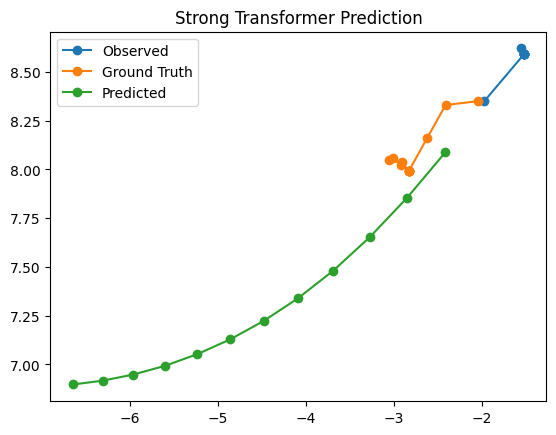

In [27]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, gt.shape[0])

obs = data['input'][idx]
gt_traj = gt[idx]
pr_traj = pr[idx]

plt.figure()
plt.plot(obs[:,0], obs[:,1], marker='o')
plt.plot(gt_traj[:,0], gt_traj[:,1], marker='o')
plt.plot(pr_traj[:,0], pr_traj[:,1], marker='o')

plt.legend(["Observed", "Ground Truth", "Predicted"])
plt.title("Strong Transformer Prediction")
plt.show()

The model is performing worse. It mostly has an overfitting issue

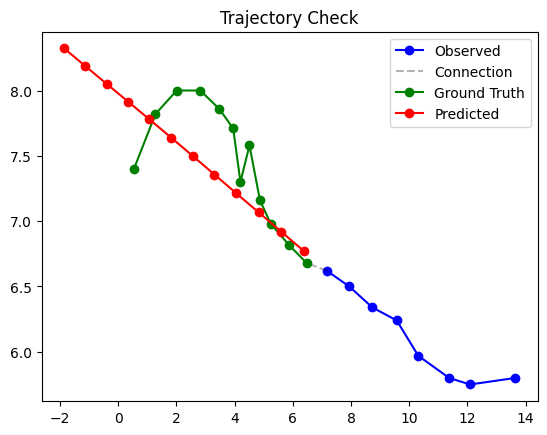

In [28]:
idx = 0  # fixed index for clarity

obs = data['input'][idx]
gt_traj = data['gt'][idx]
pr_traj = data['pr'][idx]

plt.figure()

# observed
plt.plot(obs[:,0], obs[:,1], 'bo-')

# connect observed to future
plt.plot([obs[-1,0], gt_traj[0,0]],
         [obs[-1,1], gt_traj[0,1]], 'k--', alpha=0.3)

# ground truth
plt.plot(gt_traj[:,0], gt_traj[:,1], 'go-')

# prediction
plt.plot(pr_traj[:,0], pr_traj[:,1], 'ro-')

plt.legend(["Observed", "Connection", "Ground Truth", "Predicted"])
plt.title("Trajectory Check")
plt.show()